# 0. 加载包

In [1]:
import os
import typing
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import collections
import math
import scipy.stats
from scipy.stats import gaussian_kde, variation
from scipy.stats import pearsonr
import sys
from PIL import Image

In [2]:
from scipy.stats import ttest_ind

In [3]:
import re

In [4]:
%matplotlib inline

In [5]:
default_pal = sns.color_palette()

In [6]:
from scipy.stats import gaussian_kde, pearsonr

In [7]:
%config InlineBackend.figure_format = 'retina'

In [8]:
from scipy import stats
import numpy as np
from scipy.stats import mannwhitneyu

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import PatchCollection

In [10]:
import pickle

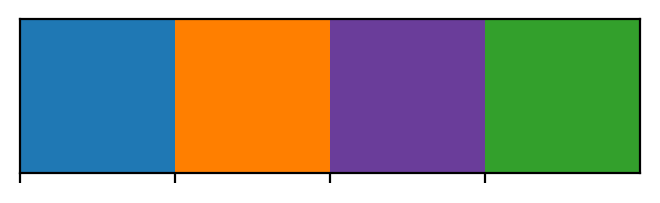

In [11]:
# setting color palette
import seaborn as sns
pal = sns.color_palette('Paired')
#pal = [pal[i] for i in (0,1, 6,7, 8 ,9,2 ,3)]
pal = [pal[i] for i in (1, 7, 9 ,3)]
sns.set_palette(pal)
sns.palplot(pal)


# 1 函数和数据

## 1.1 函数

In [12]:
#定义函数：绘制样本中reads的A尾分布的直方图，使用第一个数据框的数据
def plot_hist_samples_polya_length(xs,
                                   samples,
                                   bin_length=1,
                                   min_length=10, 
                                   max_length = 300, 
                                   figsize=None, 
                                   linewidth=2, 
                                   linestyle=None, 
                                   color=None, 
                                   plot_legend=True, 
                                   ax=None,
                                   xlab="Poly(A) tail length",
                                   ylab="Ratio of Reads"):
    
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        
    for sample, x in zip(samples, xs):
        x = x[(x >= min_length) & (x <= max_length)]
        w = np.ones(len(x)) / x.sum()
        ax.hist(
            x,
            bins = np.arange(min_length, max_length, bin_length),
            weights=w,
            histtype="step",
            label=sample,
            density=True,
            linewidth=linewidth,
            linestyle=linestyle,
            color=color
        )
        
    ax.set_ylim(0)
    ax.set_xlim(10, max_length)

    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    if plot_legend:
        plt.legend(bbox_to_anchor=[1, 0.5])

In [13]:
#函数从tree文件获取基因id
import sys
import ete3

def get_tree_node(filename):
    # read the contents of the file
    with open(filename, 'r') as f:
        treefile = f.read()

    # parse the tree file and extract the node names
    t = ete3.Tree(treefile, format=1)
    node_names = []
    for node in t.traverse():
        node_name = node.name.strip()
        if node_name:  # 检查节点名称是否非空
            split_names = node_name.split("id_")
            if len(split_names) > 1:
                second_name = split_names[1]
                node_names.append(second_name)
                if node_names[-1].endswith('Artha'):
                    node_names[-1] = re.sub('\.\d+', '', node_names[-1])
                if node_names[-1].endswith('Cydeb'):
                    node_names[-1] = re.sub(r'(evmmodelcontig(\d{6}))(\d+)', r'evm.model.contig\2.\3', node_names[-1])
                if node_names[-1].endswith('Orsat'):
                    node_names[-1] = node_names[-1].replace('_', '', 1)                              
                if re.search(r'(Cypan|Mabio)$', node_names[-1]):
                    node_names[-1] = re.sub(r'_(.*)', r'-\1', node_names[-1], count=1)
                if node_names[-1].endswith('Trwil'):
                    del node_names[-1]

    # 对节点名称进行排序
    sorted_node_names = sorted(node_names)
    # 返回节点名称列表
    return sorted_node_names

def get_OG_ID(filename):
    base_name = os.path.basename(filename)
    OG_ID = os.path.splitext(base_name)[0]
    return OG_ID

In [14]:
# 1.定义一个函数，接收tree_file和data_frames作为参数.获得tree文件的基因的polya
def get_result_df(tree_file, data_frames):
    gene_list = get_tree_node(tree_file)
    result_df = pd.DataFrame()
    
    for gene in gene_list:
        species = gene[-5:]
        gene_name = gene[:-6]
        species_data = data_frames.get(species)
        
        if species_data is not None:
            matching_rows = species_data[species_data['pepid'] == gene_name]
            matching_rows = matching_rows[['read_core_id', 'chr', 'mRNA', 'type', 'species', 'polya_length', 'pepid']]
            result_df = pd.concat([result_df, matching_rows])
    
    result_df = result_df[(result_df['polya_length'] > 10) & (result_df['polya_length'] < 300)]
    result_df['species'] = result_df['species'].replace(mapping)
    result_df['all_name'] = result_df['species'].astype(str) + "_" + result_df['pepid'].astype(str)
    
    gene_counts = result_df['all_name'].value_counts()
    selected_genes = gene_counts[gene_counts > 10].index
    result_df = result_df[result_df['all_name'].isin(selected_genes)]
    
    return result_df

In [15]:
#函数1，计算2列基因的ks分布
def calculate_ks_statistics(wgd_df, gene_to_polya_map):
    """
    计算KS检验统计量和p值的函数。
    
    :param wgd_df: 包含'gene01'和'gene02'列的DataFrame。
    :param gene_to_polya_map: 一个字典，键是基因名，值是对应的polyA位点数据列表。
    :return: 包含基因对和它们KS检验结果的列表。
    """
    results = []
    for index, row in wgd_df.iterrows():
        gene01_data = gene_to_polya_map.get(row['gene01'], [])
        gene02_data = gene_to_polya_map.get(row['gene02'], [])
        if gene01_data and gene02_data:
            stat, p_value = stats.ks_2samp(gene01_data, gene02_data)
            results.append({
                'gene01': row['gene01'],
                'gene02': row['gene02'],
                'stat': stat,
                'p_value': p_value
            })
    return results

In [16]:
#函数2，从median的pear文件中，产生随机基因对
def generate_random_gene_pairs(pair_df, n_iterations):
    """
    生成随机基因对的函数。
    :param pair_df: 包含pepid和all_median_polya列的DataFrame。
    :param n_iterations: 重复生成随机对的次数。
    :return: 包含随机基因对和它们的'random-delta'值的DataFrame。
    """
    np.random.seed(1234)  # 为了可重复性设置随机种子
    result_data = pd.DataFrame(columns=['gene01', 'gene02', 'random-delta'])

    for _ in range(n_iterations):
        random_rows = pair_df.sample(n=2, replace=False)
        random_gene01, random_gene02 = random_rows['pepid'].values
        random_delta = abs(random_rows['all_median_polya'].iloc[0] - random_rows['all_median_polya'].iloc[1])
        
        result_data = result_data.append({
            'gene01': random_gene01,
            'gene02': random_gene02,
            'random-delta': random_delta
        }, ignore_index=True)

    return result_data

## 1.2 读数据

In [17]:
def lp(pkl):
    with open(pkl, "rb") as fh:
        data = pickle.load(fh)
    return data

In [18]:
data_frames=lp("/data/Zhaijx/cheny/project/04.polyA_evo/12.all_pep/pepid_polya_median/all_species.pep_median.pickle")

# 2 物种多个WGD时间和产生随机对

## 2.1 大豆-基因对来自焦

In [105]:
#1.基因的polya median数据
pair=data_frames["Glmax"]

In [106]:
pair.head()

,mRNA,all_n_read,all_median_polya,all_mean_polya,ir_n_read,ir_median_polya,ir_mean_polya,spliced_n_read,spliced_median_polya,spliced_mean_polya,pepid
0,Glyma.01G000400.1,19,120.37,111.155263,0,0.0,0.0,15,120.370,110.271333,Glyma.01G000400
1,Glyma.01G000600.2,11,40.57,75.820000,0,0.0,0.0,4,30.380,29.095000,Glyma.01G000600
2,Glyma.01G000900.1,21,102.82,115.726190,0,0.0,0.0,0,0.000,0.000000,Glyma.01G000900
3,Glyma.01G001000.1,107,92.81,104.984393,0,0.0,0.0,21,92.010,104.498095,Glyma.01G001000
4,Glyma.01G001100.1,17,169.48,173.315882,0,0.0,0.0,10,191.995,204.426000,Glyma.01G001100


In [107]:
# 2.焦老师给的基因对
wgd=pd.read_csv("/data/Zhaijx/cheny/project/04.polyA_evo/13.WGD/21.soybean/wgd_from_jiao/all_soybean_wgd.list", sep="\t", header=0,na_values="NA",comment='#') 


In [108]:
# 3.基因对的median数据，加上去
wgd = wgd.merge(pair[['pepid', 'all_n_read', 'all_median_polya']], left_on='gene01', right_on='pepid', how='left')
wgd.drop(wgd.columns[3], axis=1, inplace=True)
wgd.rename(columns={wgd.columns[3]: 'gene01_n_reads', wgd.columns[4]: 'gene01_median'}, inplace=True)
#第二个基因对
wgd = wgd.merge(pair[['pepid', 'all_n_read', 'all_median_polya']], left_on='gene02', right_on='pepid', how='left')
wgd.drop(wgd.columns[5], axis=1, inplace=True)
wgd.rename(columns={wgd.columns[5]: 'gene02_n_reads', wgd.columns[6]: 'gene02_median'}, inplace=True)

In [109]:
# 4.筛选一下
wgd = wgd[(wgd['gene01_n_reads'] > 50) & (wgd['gene02_n_reads'] > 50)]


In [96]:
wgd.head()

,gene01,gene02,wgd,gene01_n_reads,gene01_median,gene02_n_reads,gene02_median
4,Glyma.01G016500,Glyma.09G206300,Glycine_specific_WGD,185.0,105.18,78.0,76.330
5,Glyma.13G063700,Glyma.19G021500,Glycine_specific_WGD,73.0,74.85,115.0,83.890
21,Glyma.20G099300,Glyma.10G290000,Glycine_specific_WGD,355.0,102.52,248.0,88.725
22,Glyma.02G094100,Glyma.18G287600,Glycine_specific_WGD,168.0,85.04,323.0,87.590
23,Glyma.20G099300,Glyma.02G094100,Glycine_specific_WGD,355.0,102.52,168.0,85.040


In [110]:
print('\u03b1\u1d33')
print('\u03b2\u1d33')
print('\u03b3')

αᴳ
βᴳ
γ


In [111]:
wgd['wgd'] = wgd['wgd'].replace('Glycine_specific_WGD', '\u03b1\u1d33')
wgd['wgd'] = wgd['wgd'].replace('legume_WGD', '\u03b2\u1d33')
wgd['wgd'] = wgd['wgd'].replace('gamma_WGT', '\u03b3')

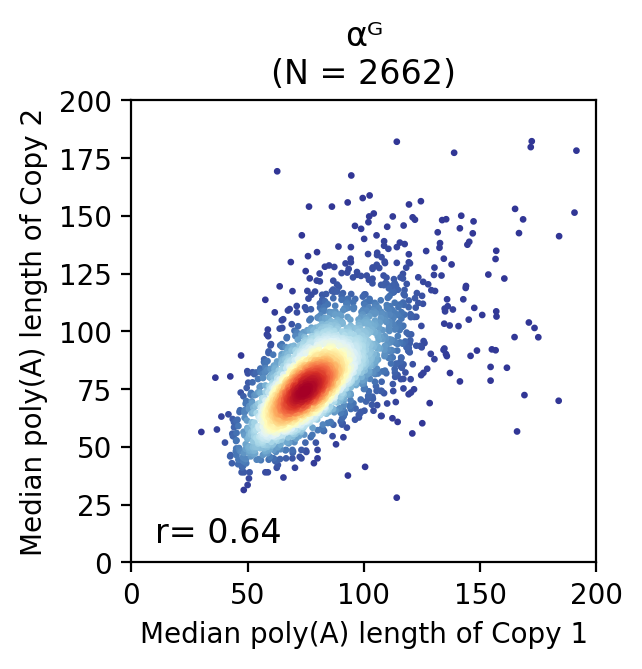

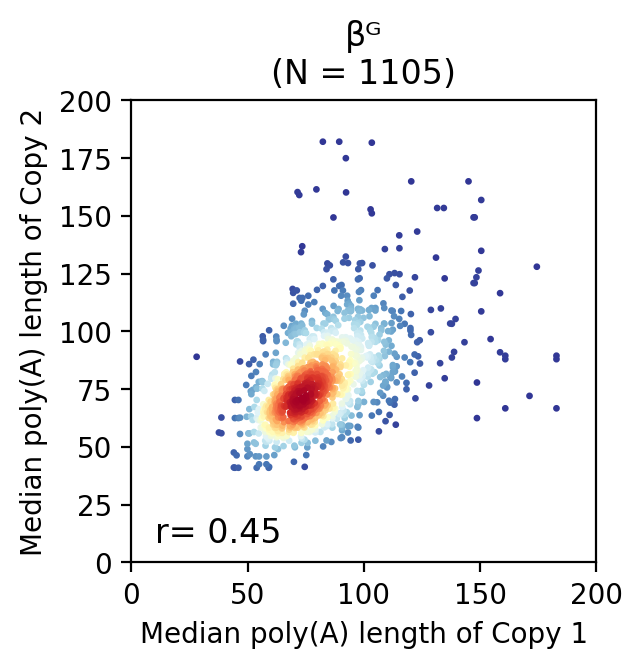

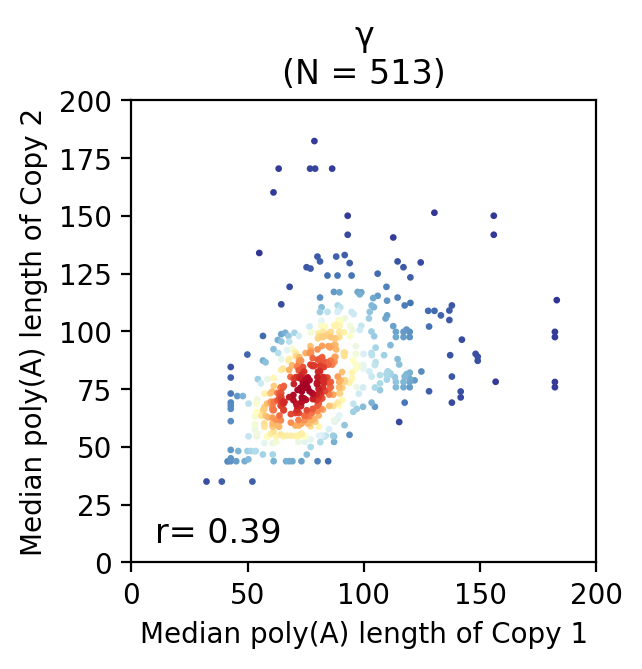

In [21]:
# 针对每个子类型逐个绘制散点图
from scipy.stats import spearmanr
for subtype in wgd['wgd'].unique():
    # 根据子类型过滤数据
    data = wgd[wgd['wgd'] == subtype]
    x = data['gene01_median']
    y = data['gene02_median']
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    idx = z.argsort()
    x, y, z = x.iloc[idx], y.iloc[idx], z[idx]
    correlation, p_value = pearsonr(x, y)
    # 创建散点图
    fig, ax = plt.subplots(figsize=(3,3), dpi=100)
    scatter = ax.scatter(x, y, marker='o', c=z, s=2, cmap="RdYlBu_r", label='LST')
    ax.text(0.05, 0.1, f"r= {correlation:.2f}", transform=ax.transAxes, fontsize=12, verticalalignment='top')

    # 设置图表标题和轴标签
    plt.xlabel('Median poly(A) length of Copy 1')
    plt.ylabel('Median poly(A) length of Copy 2')
    
    length = len(data)
    string = "{}\n(N = {})".format(subtype,length)
    #sample_name="Glycine max"
    title=string
    
    plt.title(string)
    plt.xlim(0, 200)
    plt.ylim(0, 200)
    # 显示图形
    #plt.legend()
    plt.show()

## 2.2 玉米——来自焦

### 1.2.1 基因对的median比较

In [19]:
#1.基因的polya median数据
pair=data_frames["Zemay"]

In [20]:
# 去掉末端的点和数字
pair.iloc[:, -1] = pair.iloc[:, -1].str.replace(r'\.\d+$', '', regex=True)

In [22]:
# 2.焦老师给的基因对
wgd=pd.read_csv("/data/Zhaijx/cheny/project/04.polyA_evo/13.WGD/22.maize/wgd_jiao/final.all_maize_wgd.list", sep="\t", header=0,na_values="NA",comment='#') 


In [23]:
# 3.基因对的median数据，加上去
wgd = wgd.merge(pair[['pepid', 'all_n_read', 'all_median_polya']], left_on='gene01', right_on='pepid', how='left')
wgd.drop(wgd.columns[3], axis=1, inplace=True)
wgd.rename(columns={wgd.columns[3]: 'gene01_n_reads', wgd.columns[4]: 'gene01_median'}, inplace=True)
#第二个基因对
wgd = wgd.merge(pair[['pepid', 'all_n_read', 'all_median_polya']], left_on='gene02', right_on='pepid', how='left')
wgd.drop(wgd.columns[5], axis=1, inplace=True)
wgd.rename(columns={wgd.columns[5]: 'gene02_n_reads', wgd.columns[6]: 'gene02_median'}, inplace=True)

In [24]:
# 4.筛选一下
wgd = wgd[(wgd['gene01_n_reads'] > 50) & (wgd['gene02_n_reads'] > 50)]


In [25]:
wgd['wgd'].value_counts()

alpha_z    389
sigma      169
rou        133
tao        128
Name: wgd, dtype: int64

In [26]:
wgd['wgd'].unique()

array(['alpha_z', 'tao', 'sigma', 'rou'], dtype=object)

In [27]:
print('\u03C4')
print('\u03C3')
print('\u03C1')
print('\u03b1\u1DBB')

τ
σ
ρ
αᶻ


In [28]:
wgd['wgd'] = wgd['wgd'].replace('tao', '\u03C4')
wgd['wgd'] = wgd['wgd'].replace('sigma', '\u03C3')
wgd['wgd'] = wgd['wgd'].replace('rou', '\u03C1')
wgd['wgd'] = wgd['wgd'].replace('alpha_z', '\u03b1\u1DBB')

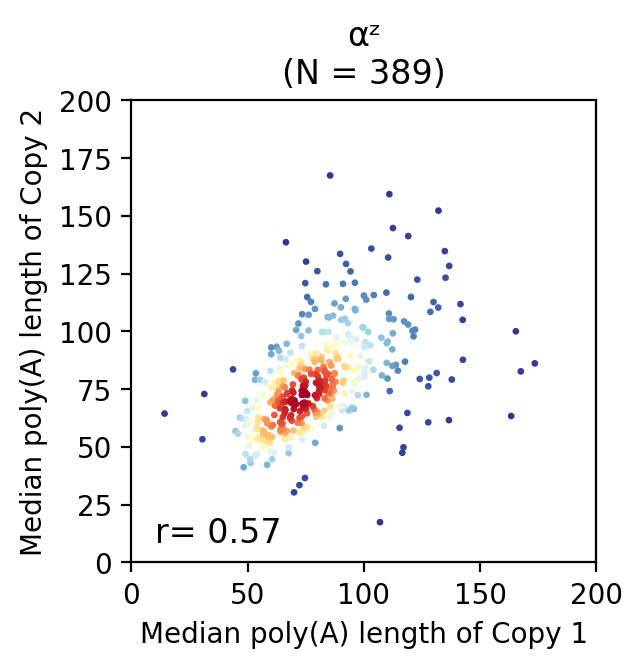

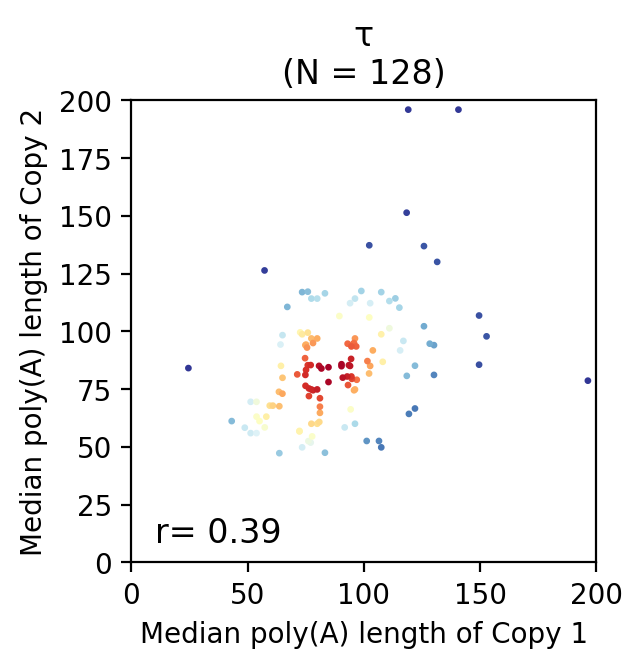

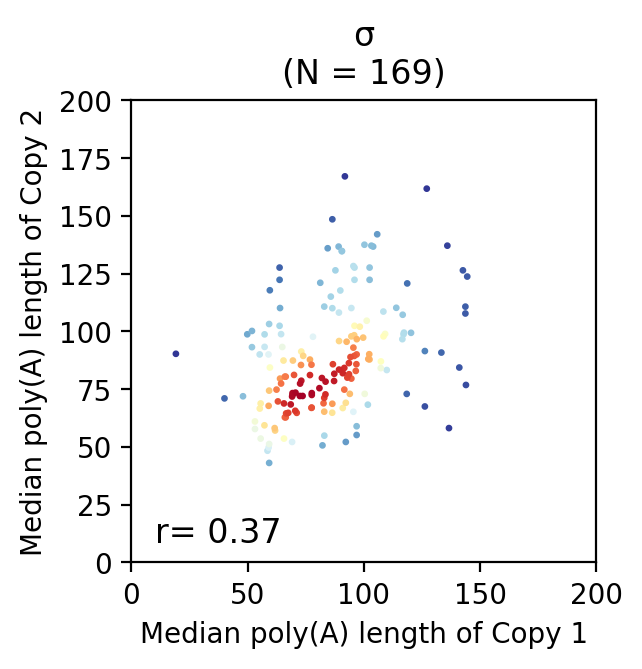

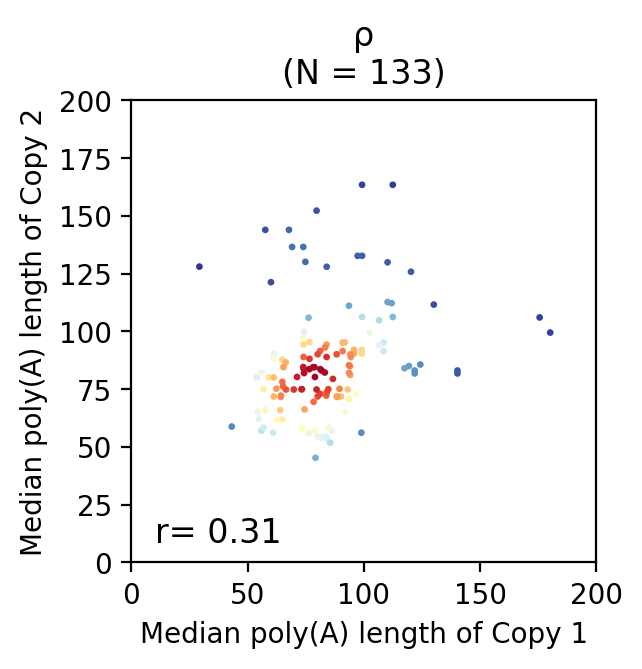

In [29]:
# 针对每个子类型逐个绘制散点图
from scipy.stats import spearmanr
for subtype in wgd['wgd'].unique():
    # 根据子类型过滤数据
    data = wgd[wgd['wgd'] == subtype]
    x = data['gene01_median']
    y = data['gene02_median']
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    idx = z.argsort()
    x, y, z = x.iloc[idx], y.iloc[idx], z[idx]
    correlation, p_value = pearsonr(x, y)
    # 创建散点图
    fig, ax = plt.subplots(figsize=(3,3), dpi=100)
    scatter = ax.scatter(x, y, marker='o', c=z, s=2, cmap="RdYlBu_r", label='LST')
    ax.text(0.05, 0.1, f"r= {correlation:.2f}", transform=ax.transAxes, fontsize=12, verticalalignment='top')

    # 设置图表标题和轴标签
    plt.xlabel('Median poly(A) length of Copy 1')
    plt.ylabel('Median poly(A) length of Copy 2')
    
    length = len(data)
    string = "{}\n(N = {})".format(subtype,length)
    #sample_name="Glycine max"
    title=string
    
    plt.title(string)
    plt.xlim(0, 200)
    plt.ylim(0, 200)
    # 显示图形
    #plt.legend()
    plt.show()

## 2.3 拟南芥——来自焦

In [132]:
#1.基因的polya median数据
pair=data_frames["Artha"]


In [133]:
# 2.焦老师给的基因对
wgd=pd.read_csv("/data/Zhaijx/cheny/project/04.polyA_evo/13.WGD/20.arabidopsis/wgd_jiao/all_ara_wgd.list", sep="\t", header=0,na_values="NA",comment='#') 


In [134]:
# 3.基因对的median数据，加上去
wgd = wgd.merge(pair[['pepid', 'all_n_read', 'all_median_polya']], left_on='gene01', right_on='pepid', how='left')
wgd.drop(wgd.columns[3], axis=1, inplace=True)
wgd.rename(columns={wgd.columns[3]: 'gene01_n_reads', wgd.columns[4]: 'gene01_median'}, inplace=True)
#第二个基因对
wgd = wgd.merge(pair[['pepid', 'all_n_read', 'all_median_polya']], left_on='gene02', right_on='pepid', how='left')
wgd.drop(wgd.columns[5], axis=1, inplace=True)
wgd.rename(columns={wgd.columns[5]: 'gene02_n_reads', wgd.columns[6]: 'gene02_median'}, inplace=True)

In [135]:
# 4.筛选一下
wgd = wgd[(wgd['gene01_n_reads'] > 50) & (wgd['gene02_n_reads'] > 50)]


In [136]:
print('\u03B1')
print('\u03B2')
print('\u03B3')

α
β
γ


In [137]:
wgd['wgd'] = wgd['wgd'].replace('Ara_a', '\u03B1')
wgd['wgd'] = wgd['wgd'].replace('Ara_b', '\u03B2')
wgd['wgd'] = wgd['wgd'].replace('Ara_gamma', '\u03B3')


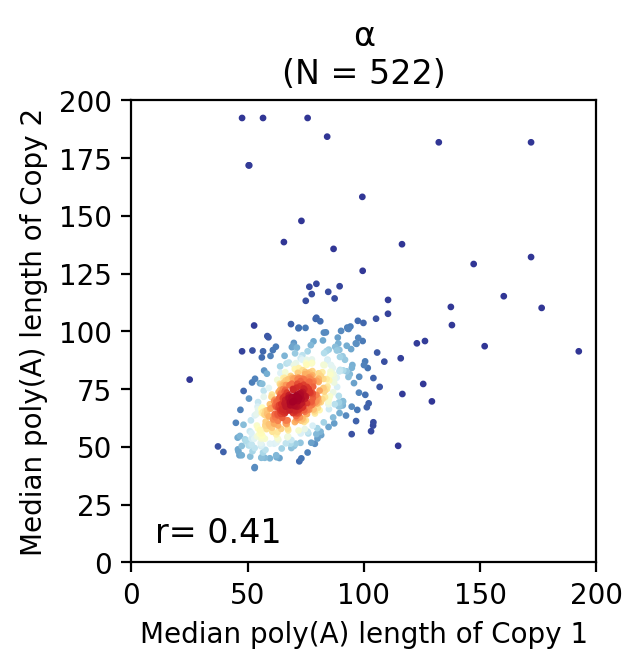

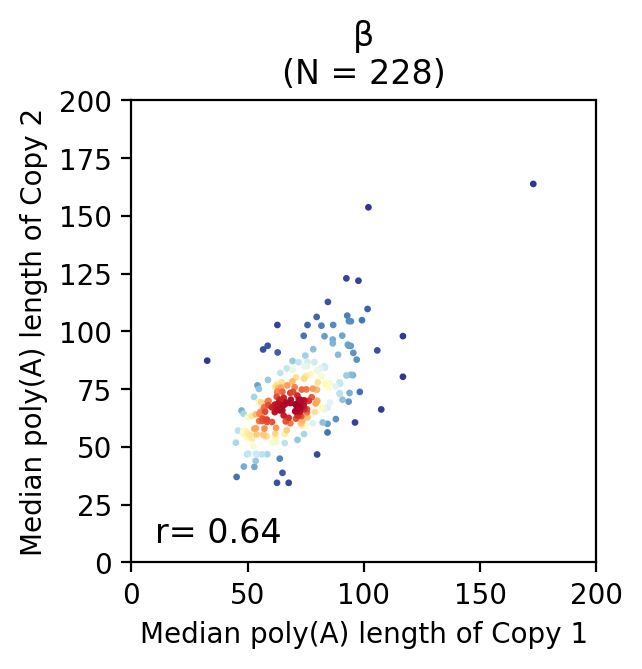

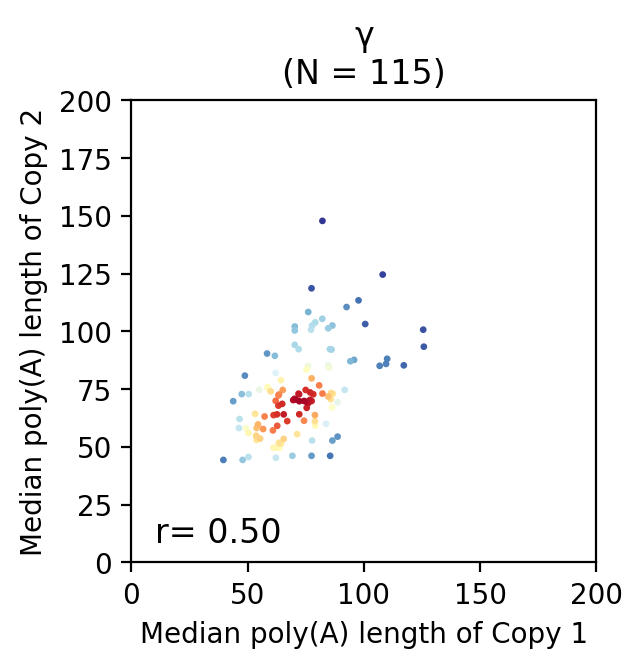

In [128]:
# 针对每个子类型逐个绘制散点图
from scipy.stats import spearmanr
for subtype in wgd['wgd'].unique():
    # 根据子类型过滤数据
    data = wgd[wgd['wgd'] == subtype]
    x = data['gene01_median']
    y = data['gene02_median']
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    idx = z.argsort()
    x, y, z = x.iloc[idx], y.iloc[idx], z[idx]
    correlation, p_value = pearsonr(x, y)
    # 创建散点图
    fig, ax = plt.subplots(figsize=(3,3), dpi=100)
    scatter = ax.scatter(x, y, marker='o', c=z, s=2, cmap="RdYlBu_r", label='LST')
    ax.text(0.05, 0.1, f"r= {correlation:.2f}", transform=ax.transAxes, fontsize=12, verticalalignment='top')

    # 设置图表标题和轴标签
    plt.xlabel('Median poly(A) length of Copy 1')
    plt.ylabel('Median poly(A) length of Copy 2')
    
    length = len(data)
    string = "{}\n(N = {})".format(subtype,length)
    #sample_name="Glycine max"
    title=string
    
    plt.title(string)
    plt.xlim(0, 200)
    plt.ylim(0, 200)
    # 显示图形
    #plt.legend()
    plt.show()

# 3.WGD基因对的分化和随机基因对的比较

## 3.1 ratio

In [114]:
test01=pd.read_csv("/data/Zhaijx/cheny/project/04.polyA_evo/13.WGD/24.mutiple_wgd/01.glmax_wgd_ks.txt", sep="\t", header=0,na_values="NA",comment='#') 
test02=pd.read_csv("/data/Zhaijx/cheny/project/04.polyA_evo/13.WGD/24.mutiple_wgd/03.zemay_wgd_ks.txt", sep="\t", header=0,na_values="NA",comment='#') 
test03=pd.read_csv("/data/Zhaijx/cheny/project/04.polyA_evo/13.WGD/24.mutiple_wgd/05.Artha_wgd_ks.txt", sep="\t", header=0,na_values="NA",comment='#') 


In [115]:
all_species_wgd=pd.concat([test01,test02,test03], ignore_index=True)
all_species_wgd['log10_pvalue'] = -np.log10(all_species_wgd['p_value'])

/data/Zhaijx/cheny/software/mambaforge-pypy3/envs/sc_py/lib/python3.8/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [116]:
all_species_wgd['group'].unique()

array(['wgd_pairs', 'random_pairs'], dtype=object)

In [117]:
all_species_wgd['group']=all_species_wgd['group'].replace("wgd_pairs", "WGD-derived pairs")
all_species_wgd['group']=all_species_wgd['group'].replace("random_pairs", "random gene pairs")

In [118]:
all_species_wgd['log10_pvalue'] = all_species_wgd['log10_pvalue'].replace('inf', np.inf)

# 然后，将np.inf值替换为30
all_species_wgd['log10_pvalue'] = all_species_wgd['log10_pvalue'].replace(np.inf, 30)

In [ ]:
significant_diff=all_species_wgd.query("p_value < 0.005")
test=significant_diff.groupby(['species', 'group']).size().unstack(fill_value=0)
test=test.reset_index()
# Set species as index
test.set_index('species', inplace=True)


In [124]:
x_order = ['Zemay','Glmax','Artha']
test = test.reindex(x_order)

In [125]:
all_species_wgd.groupby(['species', 'group']).size().unstack(fill_value=0)

group,WGD-derived pairs,random gene pairs
species,,
Artha,865,865
Glmax,4280,4280
Zemay,819,819


In [133]:
#玉米
## 卡方检验
#随机:[[有差异, 无差异],
#WGD: [有差异, 无差异]]
observed = [[221, 819-221],
            [523, 819-523]]
chi2, p, _, _ = stats.chi2_contingency(observed)
print("zeamy",p)

observed = [[945, 4280-945],
            [2410, 4280-2410]]
chi2, p, _, _ = stats.chi2_contingency(observed)
print("glmax",p)

observed = [[277, 865-277],
            [536, 865-536]]
chi2, p, _, _ = stats.chi2_contingency(observed)
print("artha",p)

zeamy 1.8883605002469963e-50
glmax 1.7912250921210478e-230
artha 1.834236031123333e-35


In [106]:
test1=all_species_wgd.groupby(['species', 'group']).size().unstack(fill_value=0)
test1=test1[['WGD-derived pairs']]
test1.columns=['all_number']


In [107]:
test=pd.merge(test1,test,left_index=True, right_index=True)
test['WGD_diff_ratio']=test['WGD-derived pairs']/test['all_number']
test['random_diff_ratio']=test['random gene pairs']/test['all_number']


In [108]:
test.head()

,all_number,WGD-derived pairs,random gene pairs,WGD_diff_ratio,random_diff_ratio
species,,,,,
Artha,865,277,536,0.320231,0.619653
Glmax,4280,945,2410,0.220794,0.563084
Zemay,819,221,523,0.269841,0.638584


In [109]:
data=test[['WGD_diff_ratio','random_diff_ratio']]

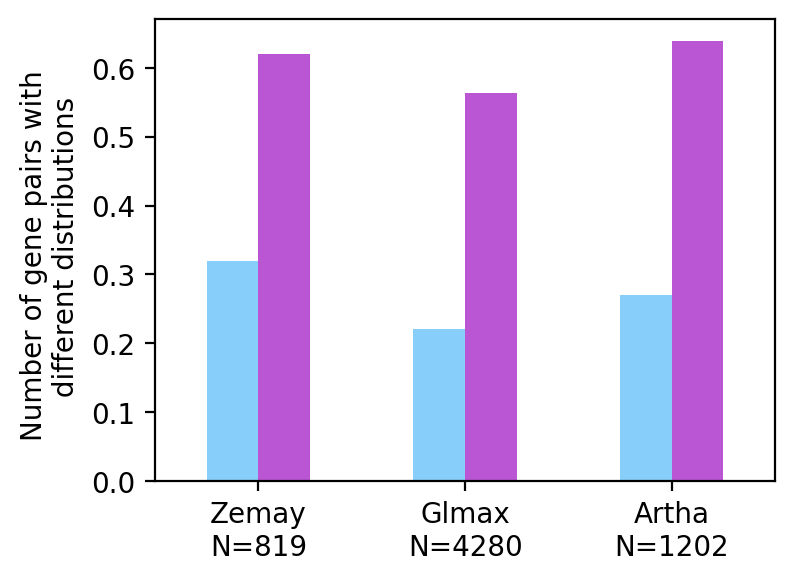

In [110]:
data.plot(kind='bar', figsize=(4, 3), color=['#87CEFA', '#BA55D3'])
plt.title('')
plt.xlabel('')
plt.ylabel('Number of gene pairs with \n different distributions')

# 设置x轴标签
x_labels = ['Zemay\nN=819', 'Glmax\nN=4280', 'Artha\nN=1202']
plt.xticks(range(len(x_labels)), x_labels, rotation=0)

# 将图例放置在上方中央，确保两张图一致
plt.legend().remove()
plt.rcParams['svg.fonttype']='none'
plt.savefig("/data/Zhaijx/cheny/project/04.polyA_evo/13.WGD/24.mutiple_wgd/wgd_vs_random_ratio.svg")
plt.show()


## 3.2 median的差值

### 大豆

In [47]:
#1.基因的polya median数据
pair=data_frames["Glmax"]

In [48]:
# 2.焦老师给的基因对
wgd=pd.read_csv("/data/Zhaijx/cheny/project/04.polyA_evo/13.WGD/21.soybean/wgd_from_jiao/all_soybean_wgd.list", sep="\t", header=0,na_values="NA",comment='#') 
# 3.基因对的median数据，加上去
wgd = wgd.merge(pair[['pepid', 'all_n_read', 'all_median_polya']], left_on='gene01', right_on='pepid', how='left')
wgd.drop(wgd.columns[3], axis=1, inplace=True)
wgd.rename(columns={wgd.columns[3]: 'gene01_n_reads', wgd.columns[4]: 'gene01_median'}, inplace=True)
#第二个基因对
wgd = wgd.merge(pair[['pepid', 'all_n_read', 'all_median_polya']], left_on='gene02', right_on='pepid', how='left')
wgd.drop(wgd.columns[5], axis=1, inplace=True)
wgd.rename(columns={wgd.columns[5]: 'gene02_n_reads', wgd.columns[6]: 'gene02_median'}, inplace=True)
# 4.筛选一下
wgd = wgd[(wgd['gene01_n_reads'] > 50) & (wgd['gene02_n_reads'] > 50)]
#计算差值的绝对值
wgd['delta'] = abs(wgd['gene01_median'] - wgd['gene02_median'])
pair=pair.query('all_n_read >50')


In [ ]:
#产生随机基因对
np.random.seed(1234)
result_data = pd.DataFrame(columns=['random_gene01', 'random_gene02', 'random-delta'])

# 重复1780次
for _ in range(4280):
    random_rows = pair.sample(n=2, replace=False)
    random_gene01, random_gene02 = random_rows['pepid'].values
    random_delta = abs(random_rows['all_median_polya'].iloc[0] - random_rows['all_median_polya'].iloc[1])
    
    # 将结果追加到result_data中
    result_data = result_data.append({
        'random_gene01': random_gene01,
        'random_gene02': random_gene02,
        'random-delta': random_delta
    }, ignore_index=True)


In [51]:
test=wgd[['gene01','gene02','delta']]
test['species'] ="Glmax"
test['group']="wgd_pairs"
result_data.columns=['gene01','gene02','delta']
result_data['species'] ="Glmax"
result_data['group']="random_pairs"

/tmp/ipykernel_23507/1145281116.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['species'] ="Glmax"
/tmp/ipykernel_23507/1145281116.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['group']="wgd_pairs"


In [52]:
all_1=pd.concat([test,result_data],ignore_index=True)

In [54]:
all_1.to_csv('/data/Zhaijx/cheny/project/04.polyA_evo/13.WGD/24.mutiple_wgd/01.delta/wgd_random_median.txt', sep='\t', index=False,mode='a')

### 拟南芥

In [55]:
#1.基因的polya median数据
pair=data_frames["Artha"]

In [56]:
# 2.焦老师给的基因对
wgd=pd.read_csv("/data/Zhaijx/cheny/project/04.polyA_evo/13.WGD/20.arabidopsis/wgd_jiao/all_ara_wgd.list", sep="\t", header=0,na_values="NA",comment='#') 


In [57]:
# 3.基因对的median数据，加上去
wgd = wgd.merge(pair[['pepid', 'all_n_read', 'all_median_polya']], left_on='gene01', right_on='pepid', how='left')
wgd.drop(wgd.columns[3], axis=1, inplace=True)
wgd.rename(columns={wgd.columns[3]: 'gene01_n_reads', wgd.columns[4]: 'gene01_median'}, inplace=True)
#第二个基因对
wgd = wgd.merge(pair[['pepid', 'all_n_read', 'all_median_polya']], left_on='gene02', right_on='pepid', how='left')
wgd.drop(wgd.columns[5], axis=1, inplace=True)
wgd.rename(columns={wgd.columns[5]: 'gene02_n_reads', wgd.columns[6]: 'gene02_median'}, inplace=True)

In [58]:
# 4.筛选一下
wgd = wgd[(wgd['gene01_n_reads'] > 50) & (wgd['gene02_n_reads'] > 50)]
#计算差值的绝对值
wgd['delta'] = abs(wgd['gene01_median'] - wgd['gene02_median'])
pair=pair.query('all_n_read >50')


In [59]:
len(wgd)

865

In [60]:
#产生随机基因对
np.random.seed(1234)
result_data = pd.DataFrame(columns=['random_gene01', 'random_gene02', 'random-delta'])

# 重复1780次
for _ in range(1202):
    random_rows = pair.sample(n=2, replace=False)
    random_gene01, random_gene02 = random_rows['pepid'].values
    random_delta = abs(random_rows['all_median_polya'].iloc[0] - random_rows['all_median_polya'].iloc[1])
    
    # 将结果追加到result_data中
    result_data = result_data.append({
        'random_gene01': random_gene01,
        'random_gene02': random_gene02,
        'random-delta': random_delta
    }, ignore_index=True)


/tmp/ipykernel_23507/3382998577.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_data = result_data.append({
/tmp/ipykernel_23507/3382998577.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_data = result_data.append({
/tmp/ipykernel_23507/3382998577.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_data = result_data.append({
/tmp/ipykernel_23507/3382998577.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_data = result_data.append({
/tmp/ipykernel_23507/3382998577.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat i

/tmp/ipykernel_23507/3382998577.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_data = result_data.append({
/tmp/ipykernel_23507/3382998577.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_data = result_data.append({
/tmp/ipykernel_23507/3382998577.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_data = result_data.append({
/tmp/ipykernel_23507/3382998577.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_data = result_data.append({
/tmp/ipykernel_23507/3382998577.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat i

In [61]:
test=wgd[['gene01','gene02','delta']]
test['species'] ="Artha"
test['group']="wgd_pairs"
result_data.columns=['gene01','gene02','delta']
result_data['species'] ="Artha"
result_data['group']="random_pairs"

/tmp/ipykernel_23507/670401117.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['species'] ="Artha"
/tmp/ipykernel_23507/670401117.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['group']="wgd_pairs"


In [62]:
all_2=pd.concat([test,result_data],ignore_index=True)

In [63]:
all_2.to_csv('/data/Zhaijx/cheny/project/04.polyA_evo/13.WGD/24.mutiple_wgd/01.delta/wgd_random_median.txt', sep='\t', index=False,mode='a')

### 玉米

In [61]:
#1.基因的polya median数据
pair=data_frames["Zemay"]

In [62]:
# 去掉末端的点和数字
pair.iloc[:, -1] = pair.iloc[:, -1].str.replace(r'\.\d+$', '', regex=True)

In [63]:
# 2.焦老师给的基因对
wgd=pd.read_csv("/data/Zhaijx/cheny/project/04.polyA_evo/13.WGD/22.maize/wgd_jiao/final.all_maize_wgd.list", sep="\t", header=0,na_values="NA",comment='#') 


In [64]:
# 3.基因对的median数据，加上去
wgd = wgd.merge(pair[['pepid', 'all_n_read', 'all_median_polya']], left_on='gene01', right_on='pepid', how='left')
wgd.drop(wgd.columns[3], axis=1, inplace=True)
wgd.rename(columns={wgd.columns[3]: 'gene01_n_reads', wgd.columns[4]: 'gene01_median'}, inplace=True)
#第二个基因对
wgd = wgd.merge(pair[['pepid', 'all_n_read', 'all_median_polya']], left_on='gene02', right_on='pepid', how='left')
wgd.drop(wgd.columns[5], axis=1, inplace=True)
wgd.rename(columns={wgd.columns[5]: 'gene02_n_reads', wgd.columns[6]: 'gene02_median'}, inplace=True)
# 4.筛选一下
wgd = wgd[(wgd['gene01_n_reads'] > 50) & (wgd['gene02_n_reads'] > 50)]
#计算差值的绝对值
wgd['delta'] = abs(wgd['gene01_median'] - wgd['gene02_median'])
pair=pair.query('all_n_read >50')

In [65]:
len(wgd)

819

In [66]:
#产生随机基因对
np.random.seed(1234)
result_data = pd.DataFrame(columns=['random_gene01', 'random_gene02', 'random-delta'])

# 重复1780次
for _ in range(819):
    random_rows = pair.sample(n=2, replace=False)
    random_gene01, random_gene02 = random_rows['pepid'].values
    random_delta = abs(random_rows['all_median_polya'].iloc[0] - random_rows['all_median_polya'].iloc[1])
    
    # 将结果追加到result_data中
    result_data = result_data.append({
        'random_gene01': random_gene01,
        'random_gene02': random_gene02,
        'random-delta': random_delta
    }, ignore_index=True)


/tmp/ipykernel_79194/4097898843.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_data = result_data.append({
/tmp/ipykernel_79194/4097898843.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_data = result_data.append({
/tmp/ipykernel_79194/4097898843.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_data = result_data.append({
/tmp/ipykernel_79194/4097898843.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_data = result_data.append({
/tmp/ipykernel_79194/4097898843.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat i

In [67]:
test=wgd[['gene01','gene02','delta']]
test['species'] ="Zemay"
test['group']="wgd_pairs"
result_data.columns=['gene01','gene02','delta']
result_data['species'] ="Zemay"
result_data['group']="random_pairs"

/tmp/ipykernel_79194/162727377.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['species'] ="Zemay"
/tmp/ipykernel_79194/162727377.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['group']="wgd_pairs"


In [68]:
all_3=pd.concat([test,result_data],ignore_index=True)

In [301]:
all_3.to_csv('/data/Zhaijx/cheny/project/04.polyA_evo/13.WGD/24.mutiple_wgd/01.delta/wgd_random_median.txt', sep='\t', index=False,mode='a')

### 合并全部

In [76]:
final = pd.read_csv('/data/Zhaijx/cheny/project/04.polyA_evo/13.WGD/24.mutiple_wgd/01.delta/wgd_random_median.txt', sep="\t", header=0, na_values="NA")

In [77]:
final = final[final['gene01'] != 'gene01']

In [78]:
final['delta'] = final['delta'].astype(float)


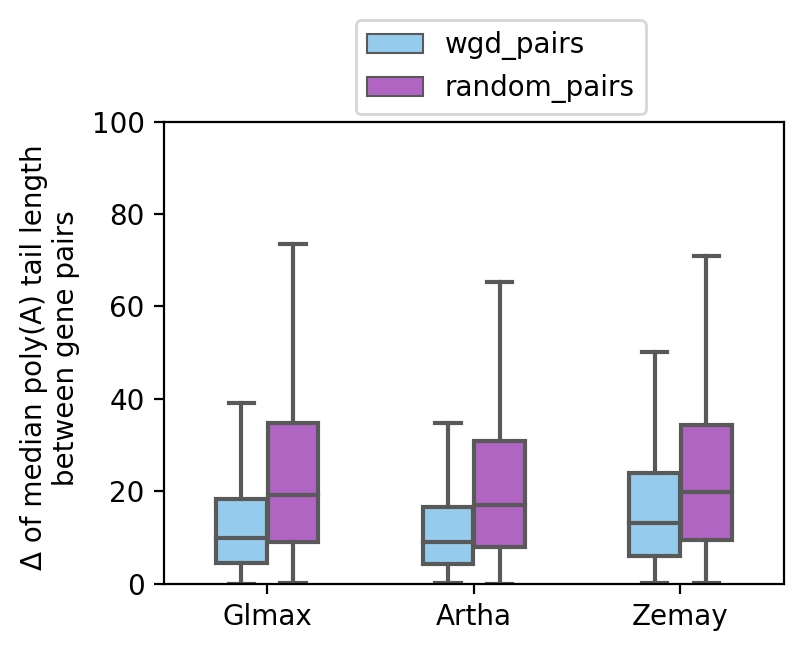

In [79]:
plt.figure(figsize=(4,3))
sns.boxplot(x='species', y='delta', hue='group', data=final,showfliers=False,width=0.5,palette={"wgd_pairs": "#87CEFA", "random_pairs": "#BA55D3"})

# Add labels and title
delta = "\u0394"
plt.xlabel('')
plt.ylabel(f"{delta} of median poly(A) tail length \n between gene pairs")
plt.title('')
plt.ylim(0,100)
plt.legend(title='', bbox_to_anchor=(0.8, 1.25))

plt.rcParams['svg.fonttype']='none'
plt.savefig("/data/Zhaijx/cheny/project/04.polyA_evo/13.WGD/24.mutiple_wgd/wgd_vs_random_median.svg")
plt.show()
